<a href="https://colab.research.google.com/github/DeepthiGovindapuram/PredictiveAnalysis/blob/LAP/lap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9
              precision    recall  f1-score   support

           0       0.90      0.99      0.95       181
           1       0.00      0.00      0.00        19

    accuracy                           0.90       200
   macro avg       0.45      0.50      0.47       200
weighted avg       0.82      0.90      0.86       200

[[180   1]
 [ 19   0]]


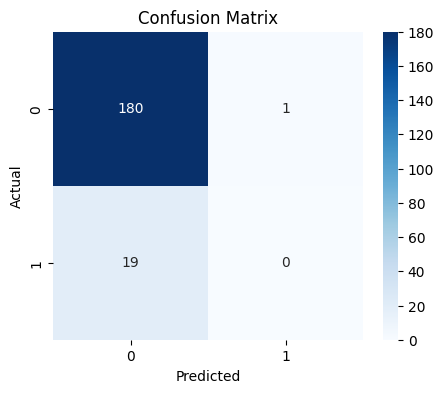

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

np.random.seed(42)
n_samples = 1000

data = pd.DataFrame({
    "ApplicantIncome": np.random.randint(2000, 15000, n_samples),
    "CoapplicantIncome": np.random.randint(0, 8000, n_samples),
    "LoanAmount": np.random.randint(50, 500, n_samples),
    "Loan_Amount_Term": np.random.choice([360, 180, 120, 60], n_samples),
    "Credit_History": np.random.randint(0, 2, n_samples),
    "Gender": np.random.randint(0, 2, n_samples),
    "Married": np.random.randint(0, 2, n_samples),
    "Dependents": np.random.randint(0, 4, n_samples),
    "Education": np.random.randint(0, 2, n_samples),
    "Self_Employed": np.random.randint(0, 2, n_samples)
})

approval_prob = (
    0.00002 * data["ApplicantIncome"]
    + 0.00001 * data["CoapplicantIncome"]
    - 0.0005 * data["LoanAmount"]
    + 0.2 * data["Credit_History"]
    - 0.05 * data["Dependents"]
    + 0.05 * data["Married"]
    - 0.02 * data["Self_Employed"]
)
approval_prob += np.random.normal(0, 0.05, n_samples)
approval_prob = approval_prob.clip(0, 1)
data["Loan_Status"] = np.random.binomial(1, approval_prob)

X = data.drop(columns=["Loan_Status"])
y = data["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
